# Customer Churn Prediction Using Machine Learning
**University of Lahore – Faculty of Information Technology | Course: Artificial Intelligence**

**Student Name:** ____________________  **Roll No:** ____________________

**Goal:** Build a complete machine-learning pipeline that predicts whether a telecom customer will leave the company (**Churn = Yes**) or stay (**Churn = No**).

**Pipeline:** Data Loading → Preprocessing → EDA → Feature Engineering & Encoding → Training/Testing → Evaluation → Prediction App → Conclusion

## 1. Data Loading and Understanding
First we import the libraries and load the dataset with Pandas. The assignment names an Excel file (`.xlsx`); the same data was supplied as a `.csv`, so the code tries Excel first and falls back to CSV.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 130)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
PALETTE = {"No": "#4C78A8", "Yes": "#E45756"}

In [2]:
# Load the dataset (Excel first, CSV as fallback)
df = None
for fname, reader in [("WA_Fn-UseC_-Telco-Customer-Churn.xlsx", pd.read_excel),
                      ("WA_Fn-UseC_-Telco-Customer-Churn.csv", pd.read_csv)]:
    if Path(fname).exists():
        df = reader(fname)
        print("Loaded file:", fname)
        break
if df is None:
    raise FileNotFoundError("Put the dataset in the same folder as this notebook.")

print("Shape (rows, columns):", df.shape)
df.head()

Loaded file: WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape (rows, columns): (7043, 21)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity  \
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No   
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes   
3  7795-CFOCW    Male              0      No         No      45           No  No phone service             DSL            Yes   
4  9237-HQITU  Female              0      No         No       2          Yes                No     Fiber optic             No   

  OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          Yes               No          No          No              No  Month-to-month              Yes   
1        

In [3]:
print("Column names:")
print(list(df.columns))
print()
print("Data types:")
print(df.dtypes)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Basic statistics of numerical columns
df.describe()

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

In [6]:
# Basic statistics of text (categorical) columns
df.describe(include="object").T

                 count unique               top  freq
customerID        7043   7043        7590-VHVEG     1
gender            7043      2              Male  3555
Partner           7043      2                No  3641
Dependents        7043      2                No  4933
PhoneService      7043      2               Yes  6361
MultipleLines     7043      3                No  3390
InternetService   7043      3       Fiber optic  3096
OnlineSecurity    7043      3                No  3498
OnlineBackup      7043      3                No  3088
DeviceProtection  7043      3                No  3095
TechSupport       7043      3                No  3473
StreamingTV       7043      3                No  2810
StreamingMovies   7043      3                No  2785
Contract          7043      3    Month-to-month  3875
PaperlessBilling  7043      2               Yes  4171
PaymentMethod     7043      4  Electronic check  2365
TotalCharges      7043   6531              20.2    11
Churn             7043      

### Target variable
The column we want to predict is **`Churn`** (`Yes` = customer left, `No` = customer stayed). Because it has only two values this is a **binary classification** problem.

In [7]:
print(df["Churn"].value_counts())
print()
print((df["Churn"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: str


### What the important columns mean
| Column | Meaning (simple words) |
|---|---|
| `customerID` | Unique ID of the customer – only a label, not useful for prediction |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Personal details: gender, 65+ years old (1/0), has a partner, has dependents (children etc.) |
| `tenure` | Number of **months** the customer has stayed with the company |
| `PhoneService`, `MultipleLines` | Whether the customer has a phone line / more than one line |
| `InternetService` | Type of internet: DSL, Fiber optic or No internet |
| `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport` | Extra protection / support services the customer pays for |
| `StreamingTV`, `StreamingMovies` | Whether the customer streams TV / movies through the company |
| `Contract` | Contract type: Month-to-month, One year, Two year |
| `PaperlessBilling`, `PaymentMethod` | How the customer receives the bill and pays it |
| `MonthlyCharges` | Amount charged every month |
| `TotalCharges` | Total amount charged since the customer joined |
| **`Churn`** | **TARGET** – did the customer leave in the last month? |

## 2. Data Preprocessing
Machine-learning models need clean, consistent, numerical data. We therefore check the quality of the data step by step.

### 2.1 Missing values
`isnull()` finds real empty cells. Columns that look numeric but are stored as text can hide problems, so we also inspect `TotalCharges`, which was read as `object` (text) instead of a number.

In [8]:
print("Missing values per column (isnull):")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No NaN values found by isnull()")
print()
print("TotalCharges data type:", df["TotalCharges"].dtype)

# Blank strings (" ") are not detected by isnull() – convert to numbers and see which fail
tc_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows where TotalCharges is blank / not a number:", tc_numeric.isnull().sum())
df[tc_numeric.isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Missing values per column (isnull):
No NaN values found by isnull()

TotalCharges data type: str
Rows where TotalCharges is blank / not a number: 11


      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

**Finding:** 11 customers have a blank `TotalCharges`. All of them have `tenure = 0`, i.e. they just joined and have not been billed yet. So the correct value is **0**, not a random guess. Dropping these rows would waste data, so we fill them with 0.

### 2.2 Incorrect data types
`TotalCharges` was read as **text** (`object`/`str`) instead of a number, because of the blank cells. It must be numeric. `SeniorCitizen` is stored as 0/1 – it is really a Yes/No category, but 0/1 is already a valid numerical encoding, so we keep it.

In [9]:
df_clean = df.copy()

# Fix TotalCharges: text -> number, blanks (new customers) -> 0
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce").fillna(0)

# Remove accidental leading/trailing spaces in all text columns
text_cols = df_clean.select_dtypes(include=["object", "string"]).columns
for c in text_cols:
    df_clean[c] = df_clean[c].str.strip()

print("TotalCharges data type now:", df_clean["TotalCharges"].dtype)
print("Missing values left:", df_clean.isnull().sum().sum())

TotalCharges data type now: float64
Missing values left: 0


### 2.3 Duplicate records
Duplicate rows would count the same customer twice and make the model over-confident, so we check both fully-duplicated rows and duplicated customer IDs.

In [10]:
print("Fully duplicated rows :", df_clean.duplicated().sum())
print("Duplicated customerIDs:", df_clean["customerID"].duplicated().sum())

Fully duplicated rows : 0
Duplicated customerIDs: 0


### 2.4 Unnecessary columns
`customerID` is a unique label. It carries no information about behaviour, and keeping it could make a model memorise IDs. We drop it.

In [11]:
df_clean = df_clean.drop(columns=["customerID"])
print("Shape after dropping customerID:", df_clean.shape)

Shape after dropping customerID: (7043, 20)


### 2.5 Inconsistent category values
Columns such as `OnlineSecurity` contain three values: `Yes`, `No` and `No internet service`. The third value simply repeats information that is already stored in `InternetService = No` (same for `No phone service` in `MultipleLines`). We merge them into `No` so that every add-on column is a clean Yes/No feature.

In [12]:
print("Before:", df_clean["OnlineSecurity"].unique(), df_clean["MultipleLines"].unique())
df_clean = df_clean.replace({"No internet service": "No", "No phone service": "No"})
print("After :", df_clean["OnlineSecurity"].unique(), df_clean["MultipleLines"].unique())

Before: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
After : <StringArray>
['No', 'Yes']
Length: 2, dtype: str <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 2.6 Outliers and unique values check
We check that numeric columns have no impossible values (negative tenure/charges) and view the unique values of every categorical column to catch spelling mistakes.

In [13]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print(df_clean[num_cols].describe().round(2))
print()
for c in num_cols:
    q1, q3 = df_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_clean[c] < q1 - 1.5 * iqr) | (df_clean[c] > q3 + 1.5 * iqr)).sum()
    print(f"{c:15s} IQR outliers: {n_out}")
print()
for c in df_clean.select_dtypes(include=["object", "string"]).columns:
    print(f"{c:18s}", df_clean[c].unique().tolist())

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

tenure          IQR outliers: 0
MonthlyCharges  IQR outliers: 0
TotalCharges    IQR outliers: 0

gender             ['Female', 'Male']
Partner            ['Yes', 'No']
Dependents         ['No', 'Yes']
PhoneService       ['No', 'Yes']
MultipleLines      ['No', 'Yes']
InternetService    ['DSL', 'Fiber optic', 'No']
OnlineSecurity     ['No', 'Yes']
OnlineBackup       ['Yes', 'No']
DeviceProtection   ['No', 'Yes']
TechSupport        ['No', 'Yes']
StreamingTV        ['No', 'Yes']
StreamingMovies    ['No', 'Yes']
Contract           ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   

**Finding:** There are no negative or impossible values and no IQR outliers, and the category spellings are consistent. The data is now clean (7,043 rows, 20 columns).

## 3. Exploratory Data Analysis (EDA)
EDA helps us understand *which customers leave* before building any model.

### 3.1 Churn distribution

Overall churn rate: 26.54%


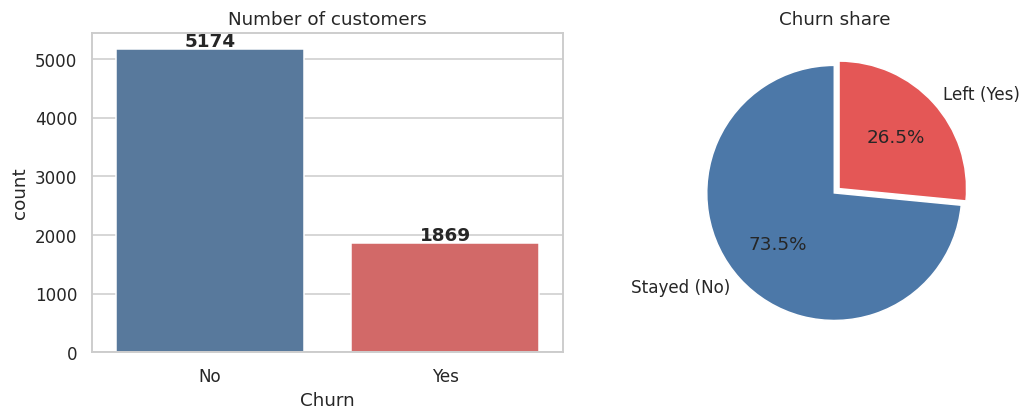

In [14]:
overall = (df_clean["Churn"] == "Yes").mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df_clean["Churn"].value_counts()
sns.countplot(data=df_clean, x="Churn", hue="Churn", palette=PALETTE, legend=False, ax=ax[0])
for i, v in enumerate(counts[["No", "Yes"]]):
    ax[0].text(i, v + 40, str(v), ha="center", fontweight="bold")
ax[0].set_title("Number of customers")
ax[1].pie(counts[["No", "Yes"]], labels=["Stayed (No)", "Left (Yes)"], autopct="%1.1f%%",
          colors=[PALETTE["No"], PALETTE["Yes"]], startangle=90, explode=[0, 0.05])
ax[1].set_title("Churn share")
plt.tight_layout()
plt.show()
print(f"Overall churn rate: {overall:.2f}%")

**Result:** about **26.5 %** of customers churned. The classes are *imbalanced* (roughly 3 stayers for every 1 leaver). This matters later: a lazy model that always predicts "No Churn" would already be ~73 % accurate, so accuracy alone is not a trustworthy metric.

### 3.2 Churn rate by customer characteristics
Each bar shows the percentage of customers in that group who churned. The dashed line is the overall churn rate (26.5 %).

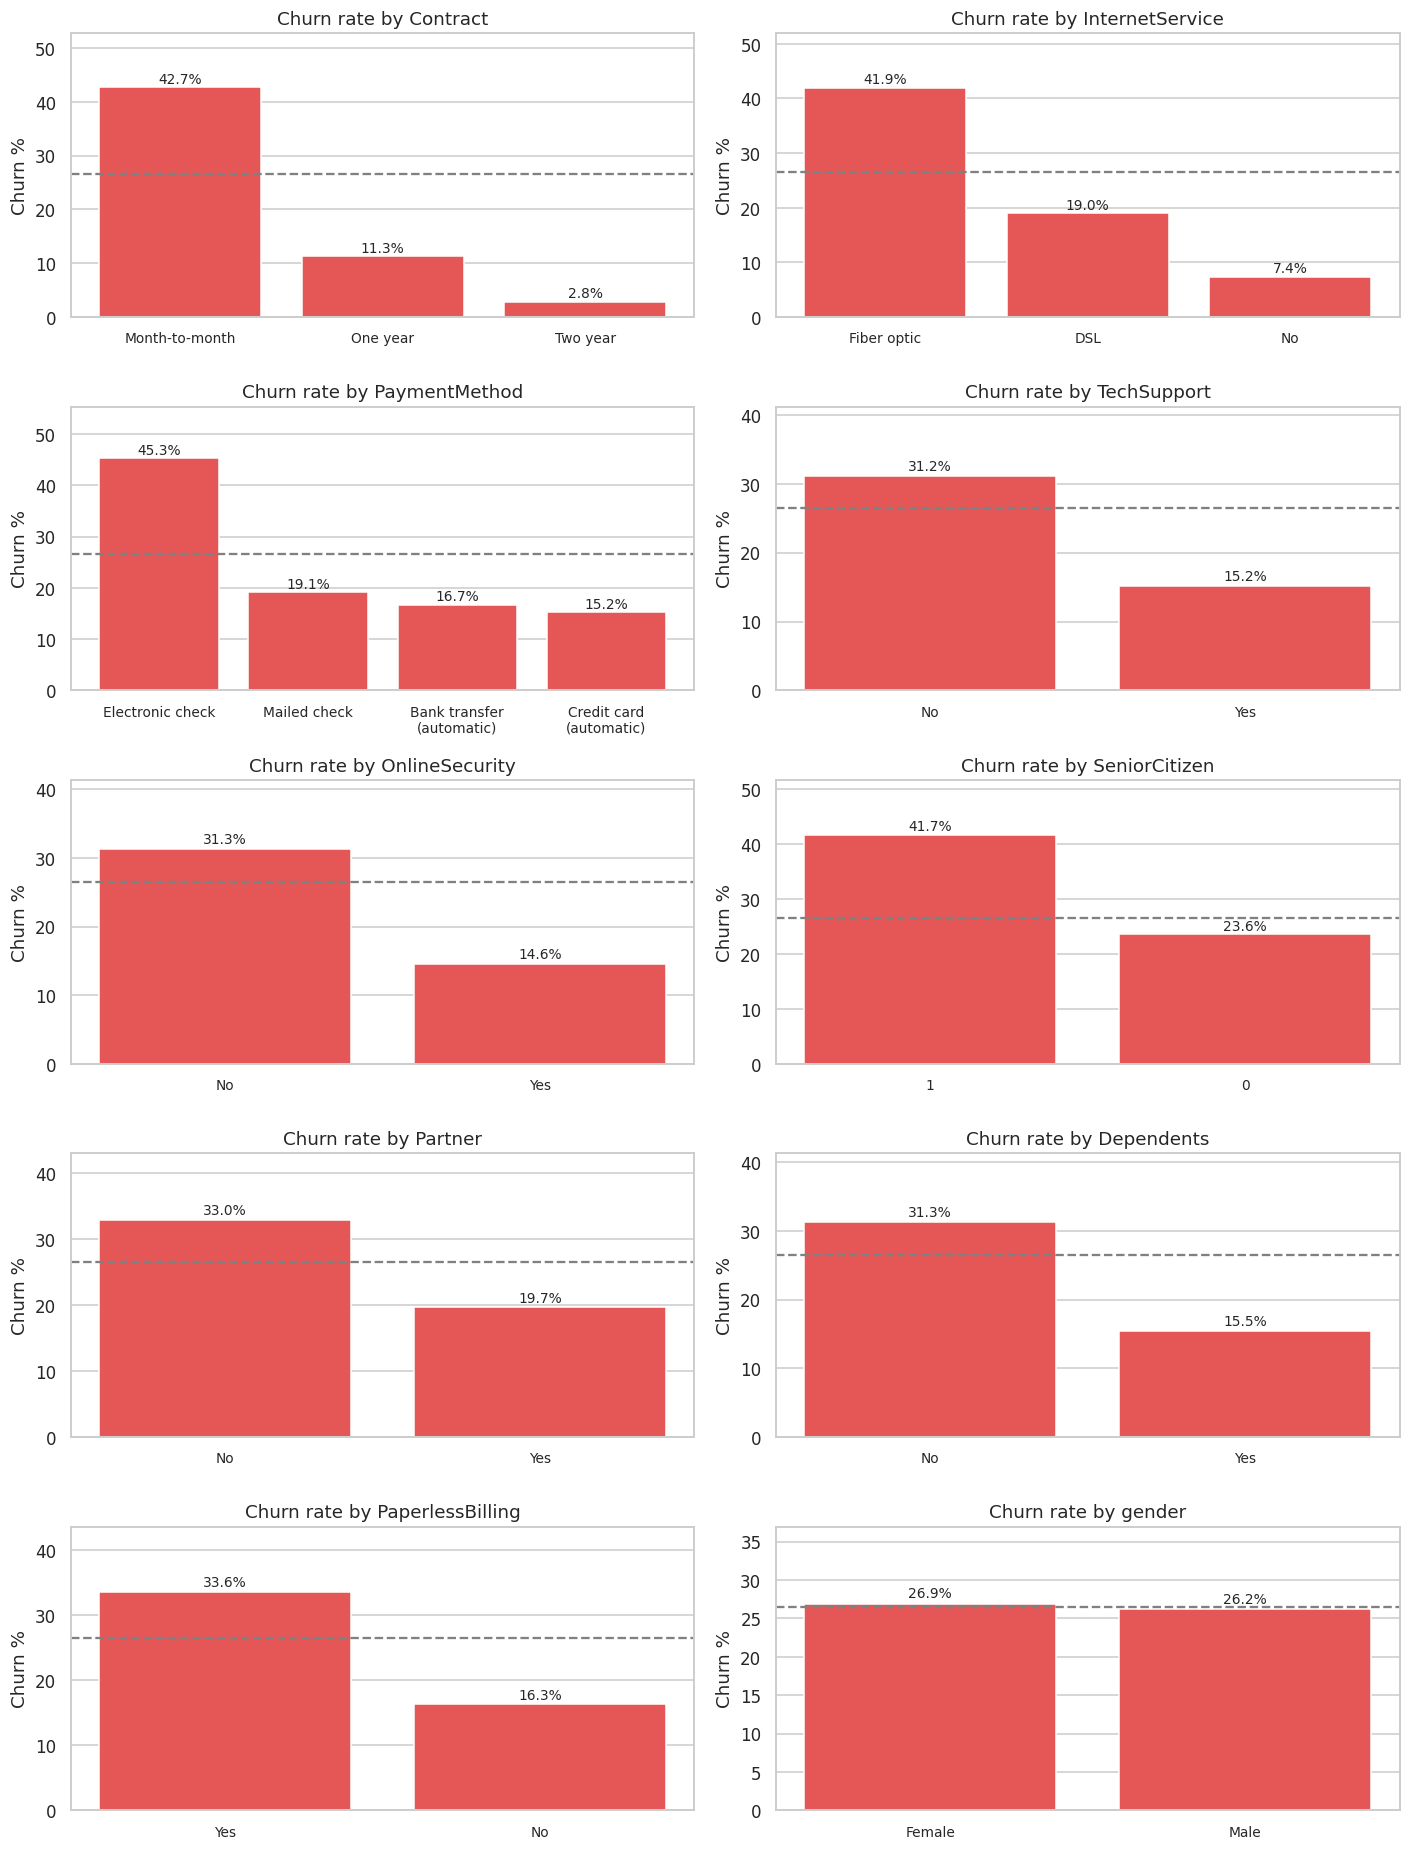

In [15]:
def churn_rate(col):
    return (df_clean.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
            .sort_values(ascending=False))

cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity",
            "SeniorCitizen", "Partner", "Dependents", "PaperlessBilling", "gender"]
fig, axes = plt.subplots(5, 2, figsize=(13, 17))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = churn_rate(col)
    bars = ax.bar([str(i).replace(" (", "\n(") for i in rate.index], rate.values, color="#E45756")
    ax.grid(axis="x", visible=False)
    ax.axhline(overall, ls="--", color="grey")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn %")
    ax.set_ylim(0, rate.max() + 10)
    ax.tick_params(axis="x", labelsize=9)
    for b, v in zip(bars, rate.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# The same numbers as a table
summary = pd.concat({c: churn_rate(c).round(1) for c in ["Contract", "InternetService", "PaymentMethod",
                                                         "SeniorCitizen", "Partner", "Dependents"]})
summary.rename("Churn %").to_frame()

                                           Churn %
Contract        Month-to-month                42.7
                One year                      11.3
                Two year                       2.8
InternetService Fiber optic                   41.9
                DSL                           19.0
                No                             7.4
PaymentMethod   Electronic check              45.3
                Mailed check                  19.1
                Bank transfer (automatic)     16.7
                Credit card (automatic)       15.2
SeniorCitizen   1                             41.7
                0                             23.6
Partner         No                            33.0
                Yes                           19.7
Dependents      No                            31.3
                Yes                           15.5

**Observations**
* **Contract is the strongest signal:** month-to-month customers churn ≈ 43 %, one-year ≈ 11 %, two-year only ≈ 3 %.
* **Fiber-optic** internet users churn ≈ 42 % compared with ≈ 19 % for DSL and ≈ 7 % for customers without internet.
* **Electronic-check** payers churn ≈ 45 %, far more than customers on automatic payments (≈ 15–17 %).
* Customers **without TechSupport / OnlineSecurity**, **senior citizens**, customers **without a partner or dependents** and **paperless-billing** customers churn more.
* **Gender** makes almost no difference (≈ 27 % vs ≈ 26 %), so it is a weak feature.

### 3.3 Tenure and charges

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


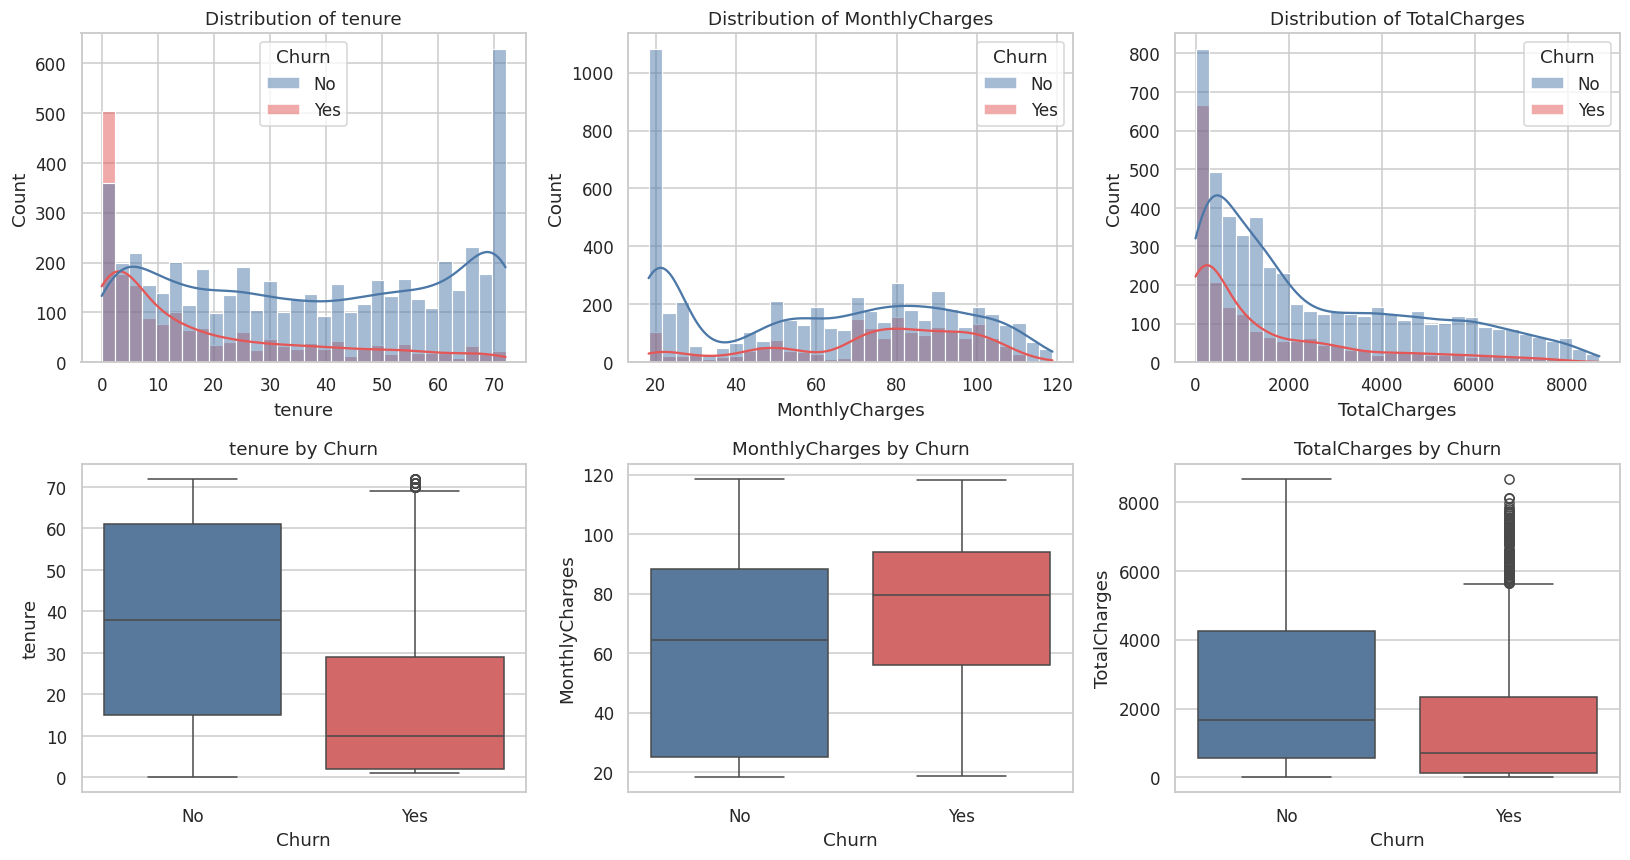

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df_clean, x=col, hue="Churn", palette=PALETTE, bins=30, kde=True, ax=ax[0, i])
    ax[0, i].set_title(f"Distribution of {col}")
    sns.boxplot(data=df_clean, x="Churn", y=col, hue="Churn", palette=PALETTE, legend=False, ax=ax[1, i])
    ax[1, i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()
print(df_clean.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2))

tenure
0-12 months     47.4
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5
Name: Churn, dtype: float64


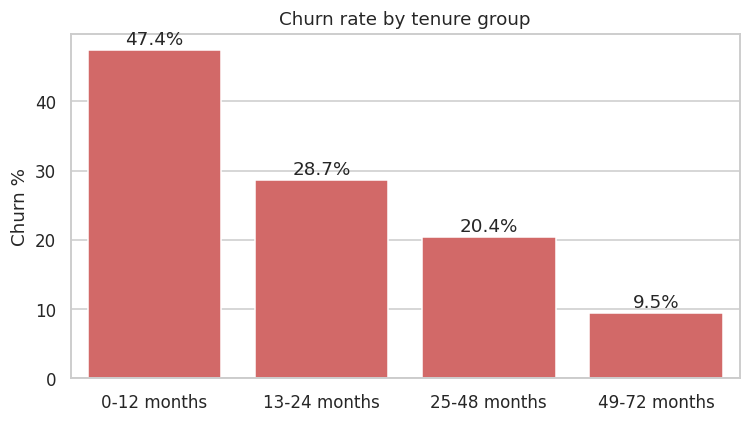

In [18]:
# Churn rate by tenure group
bins = [-1, 12, 24, 48, 72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
tenure_group = pd.cut(df_clean["tenure"], bins=bins, labels=labels)
rate = (df_clean.groupby(tenure_group)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)).round(1)
print(rate)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=rate.index.astype(str), y=rate.values, color="#E45756")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.8, f"{v}%", ha="center")
plt.title("Churn rate by tenure group"); plt.ylabel("Churn %"); plt.xlabel("")
plt.tight_layout(); plt.show()

**Observations**
* Churners have a **much shorter tenure** (mean ≈ 18 months vs ≈ 38 months for stayers). About 47 % of customers in their first year leave, while only ≈ 9.5 % of customers with more than four years of tenure do.
* Churners pay **higher monthly charges** (≈ \$74 vs ≈ \$61), which fits with the fiber-optic finding.
* `TotalCharges` is lower for churners mainly because they stayed for fewer months.

### 3.4 Correlation of numeric features with churn

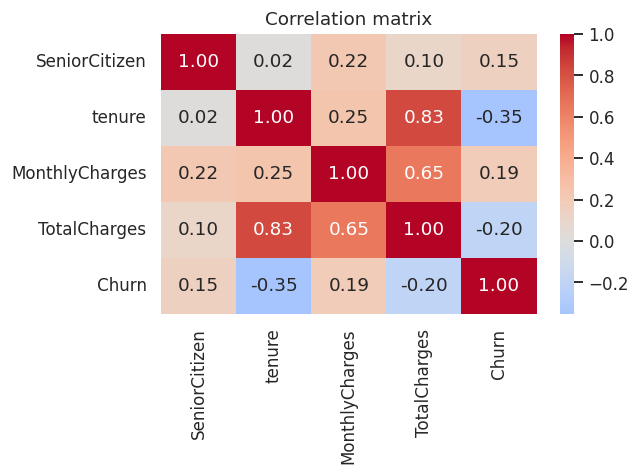

In [19]:
corr_df = df_clean[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn"] = (df_clean["Churn"] == "Yes").astype(int)
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout(); plt.show()

**Observation:** `tenure` is negatively correlated with churn (longer stay → less churn), `MonthlyCharges` is positively correlated. `tenure` and `TotalCharges` are strongly correlated with each other (TotalCharges ≈ tenure × monthly price), which is expected.

## 4. Feature Engineering and Encoding
**Feature selection**
* `customerID` was already removed.
* `gender` is dropped: EDA showed almost identical churn rates for men and women, so it adds noise rather than information.

**Feature creation**
* `NumAddOns` – how many of the 6 add-on services (security, backup, device protection, tech support, streaming TV, streaming movies) the customer has. Customers with more services are more "locked-in".
* `AutoPay` – 1 if the customer pays by automatic bank transfer or credit card (EDA showed these customers rarely churn).

**Encoding** – models only understand numbers:
* Yes/No columns → **1 / 0** (binary encoding).
* `InternetService`, `Contract`, `PaymentMethod` (3–4 unordered categories) → **one-hot encoding** (`pd.get_dummies`, `drop_first=True` to avoid redundant columns).

All steps are written in **one function** (`build_features`), so exactly the same transformation can be re-used later when we predict for new customers.

In [20]:
ADDONS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
BINARY_COLS = ["Partner", "Dependents", "PhoneService", "MultipleLines"] + ADDONS + ["PaperlessBilling"]
MULTI_COLS = ["InternetService", "Contract", "PaymentMethod"]

def build_features(data):
    """Cleaned/raw customer table -> table of numeric features (target not included)."""
    d = data.copy()
    d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0)
    d = d.replace({"No internet service": "No", "No phone service": "No"})
    # new features
    d["NumAddOns"] = (d[ADDONS] == "Yes").sum(axis=1)
    d["AutoPay"] = d["PaymentMethod"].str.contains("automatic").astype(int)
    # binary encoding (Yes -> 1, No -> 0)
    for c in BINARY_COLS:
        d[c] = (d[c] == "Yes").astype(int)
    keep = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "NumAddOns", "AutoPay"] + BINARY_COLS + MULTI_COLS
    return d[keep]

X_raw = build_features(df_clean)
print("Before one-hot encoding:", X_raw.shape)
X_raw.head()

Before one-hot encoding: (7043, 20)


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  NumAddOns  AutoPay  Partner  Dependents  PhoneService  MultipleLines  \
0              0       1           29.85         29.85          1        0        1           0             0              0   
1              0      34           56.95       1889.50          2        0        0           0             1              0   
2              0       2           53.85        108.15          2        0        0           0             1              0   
3              0      45           42.30       1840.75          3        1        0           0             0              0   
4              0       2           70.70        151.65          0        0        0           0             1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  PaperlessBilling InternetService  \
0               0             1                 0            0            0                0         

In [21]:
# One-hot encoding of the 3 multi-category columns
X = pd.get_dummies(X_raw, columns=MULTI_COLS, drop_first=True, dtype=int)

# Target variable: Yes -> 1, No -> 0
y = (df_clean["Churn"] == "Yes").astype(int)

print("X (input features) shape:", X.shape)
print("y (target) shape        :", y.shape)
print("\nAll data types numeric? ", all(np.issubdtype(t, np.number) for t in X.dtypes))
print("\nFeature columns:\n", list(X.columns))
X.head()

X (input features) shape: (7043, 24)
y (target) shape        : (7043,)

All data types numeric?  True

Feature columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddOns', 'AutoPay', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  NumAddOns  AutoPay  Partner  Dependents  PhoneService  MultipleLines  \
0              0       1           29.85         29.85          1        0        1           0             0              0   
1              0      34           56.95       1889.50          2        0        0           0             1              0   
2              0       2           53.85        108.15          2        0        0           0             1              0   
3              0      45           42.30       1840.75          3        1        0           0             0              0   
4              0       2           70.70        151.65          0        0        0           0             1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  PaperlessBilling  \
0               0             1                 0            0            0                0                 1   
1  

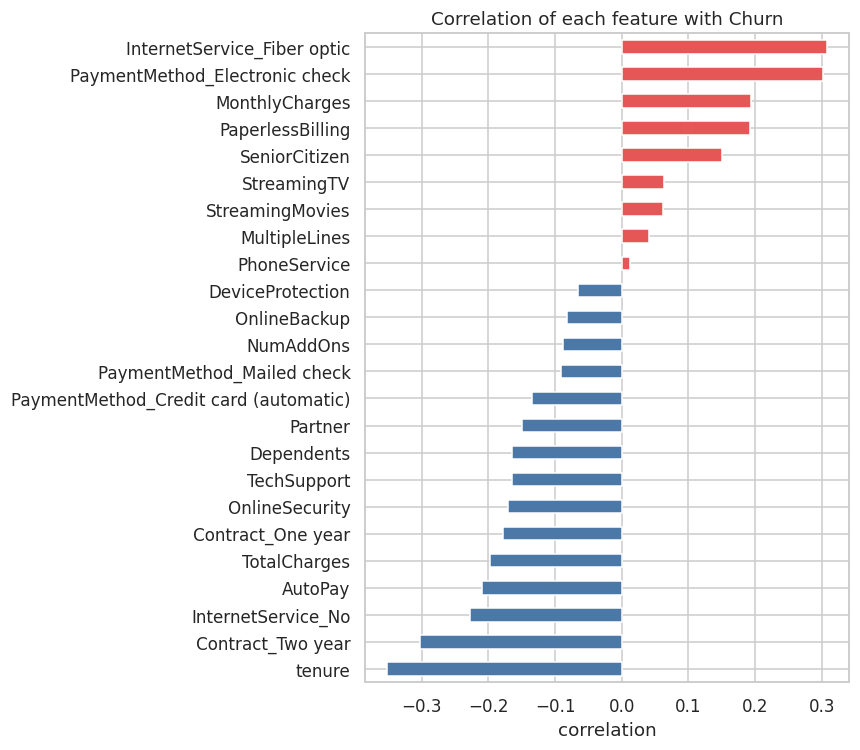

In [22]:
# Which features move together with churn? (simple correlation with the target)
corr_target = X.assign(Churn=y).corr()["Churn"].drop("Churn").sort_values()
plt.figure(figsize=(8, 7))
corr_target.plot(kind="barh", color=["#4C78A8" if v < 0 else "#E45756" for v in corr_target])
plt.title("Correlation of each feature with Churn"); plt.xlabel("correlation")
plt.tight_layout(); plt.show()

**Result:** `tenure` (−0.35), `Contract_Two year` (−0.30), `InternetService_No` (−0.23) and our new feature `AutoPay` (−0.21) are the features most linked with *staying*. `InternetService_Fiber optic` (+0.31), `PaymentMethod_Electronic check` (+0.30), `MonthlyCharges` (+0.19) and `PaperlessBilling` (+0.19) are linked with *leaving* – matching the EDA. `NumAddOns` is only weakly correlated (−0.09) but still adds some information, so it is kept. No single feature is enough on its own, which is why we use a model that combines them.

## 5. Training and Testing
### 5.1 Train/test split
We keep **80 %** of the data for training and **20 %** for testing. The model never sees the test set during training, so test scores show how it behaves on *new* customers. `stratify=y` keeps the same churn percentage in both parts (important because the data is imbalanced) and `random_state=42` makes results reproducible.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Training set:", X_train.shape, "| churn rate: %.2f%%" % (y_train.mean() * 100))
print("Testing set :", X_test.shape,  "| churn rate: %.2f%%" % (y_test.mean() * 100))

Training set: (5634, 24) | churn rate: 26.54%
Testing set : (1409, 24) | churn rate: 26.54%


### 5.2 Models
We train **three** classification algorithms:

| Model | Why it was chosen |
|---|---|
| **Logistic Regression** | Simple, fast, easy to interpret baseline. Needs scaled inputs, so it is wrapped in a pipeline with `StandardScaler`. |
| **Decision Tree** (`max_depth=5`) | Learns easy-to-read "if-then" rules and handles non-linear patterns. Depth is limited to avoid over-fitting. |
| **Random Forest** (300 trees) | Many trees voting together – usually more accurate and more stable than one tree. |

Because only ~27 % of customers churn, all models use `class_weight="balanced"`: mistakes on the rare *churn* class are penalised more, so the model pays attention to the customers we actually want to find.

In [24]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


In [25]:
# 5-fold cross-validation on the TRAINING data (checks the models are stable, not lucky)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_table = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_table[name] = {"CV F1 (mean)": scores.mean(), "CV F1 (std)": scores.std()}
pd.DataFrame(cv_table).T.round(4)

                     CV F1 (mean)  CV F1 (std)
Logistic Regression        0.6289       0.0223
Decision Tree              0.6012       0.0179
Random Forest              0.6368       0.0146

## 6. Model Evaluation
Metrics used (Churn = positive class):
* **Accuracy** – share of all predictions that are correct.
* **Precision** – of the customers predicted to churn, how many really churned.
* **Recall** – of the customers who really churned, how many we caught (most important for retention campaigns).
* **F1-score** – balance between precision and recall.
* **ROC-AUC** – how well the model ranks churners above non-churners (1.0 perfect, 0.5 random).
* **Confusion matrix** – counts of TN, FP, FN, TP.

In [26]:
rows, preds, probs = [], {}, {}
for name, model in models.items():
    preds[name] = model.predict(X_test)
    probs[name] = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, preds[name]),
        "Precision": precision_score(y_test, preds[name]),
        "Recall":    recall_score(y_test, preds[name]),
        "F1-Score":  f1_score(y_test, preds[name]),
        "ROC-AUC":   roc_auc_score(y_test, probs[name]),
    })
results = pd.DataFrame(rows).set_index("Model").round(4)
print("Baseline: a model that always says 'No Churn' has accuracy = %.4f but recall = 0\n" % (1 - y_test.mean()))
results

Baseline: a model that always says 'No Churn' has accuracy = 0.7346 but recall = 0



                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7374     0.5034  0.7834    0.6130   0.8415
Decision Tree          0.7289     0.4935  0.8102    0.6134   0.8296
Random Forest          0.7537     0.5245  0.7727    0.6249   0.8448

In [27]:
for name in models:
    print("=" * 60)
    print(name)
    print(classification_report(y_test, preds[name], target_names=["No Churn", "Churn"], digits=3))

Logistic Regression
              precision    recall  f1-score   support

    No Churn      0.902     0.721     0.801      1035
       Churn      0.503     0.783     0.613       374

    accuracy                          0.737      1409
   macro avg      0.703     0.752     0.707      1409
weighted avg      0.796     0.737     0.751      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn      0.911     0.700     0.791      1035
       Churn      0.493     0.810     0.613       374

    accuracy                          0.729      1409
   macro avg      0.702     0.755     0.702      1409
weighted avg      0.800     0.729     0.744      1409

Random Forest
              precision    recall  f1-score   support

    No Churn      0.901     0.747     0.817      1035
       Churn      0.525     0.773     0.625       374

    accuracy                          0.754      1409
   macro avg      0.713     0.760     0.721      1409
weighted avg      0.801   

Logistic Regression  TN=746  FP=289  FN=81  TP=293
Decision Tree        TN=724  FP=311  FN=71  TP=303
Random Forest        TN=773  FP=262  FN=85  TP=289


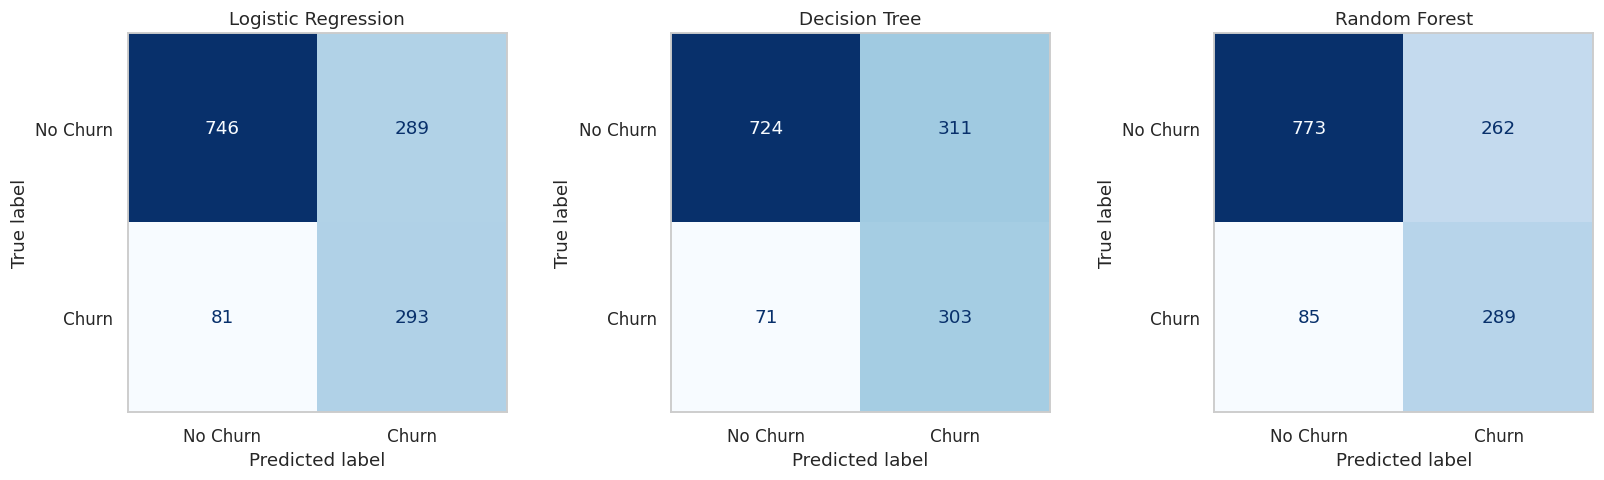

In [28]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(y_test, preds[name], display_labels=["No Churn", "Churn"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout(); plt.show()

for name in models:
    tn, fp, fn, tp = confusion_matrix(y_test, preds[name]).ravel()
    print(f"{name:20s} TN={tn}  FP={fp}  FN={fn}  TP={tp}")

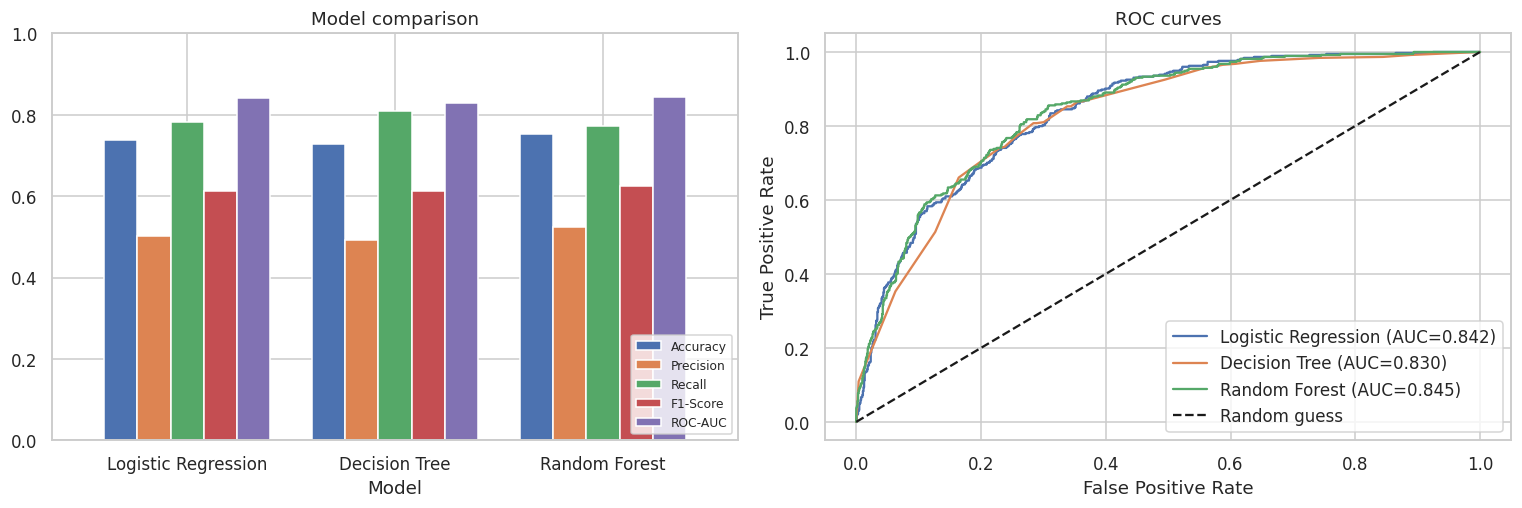

In [29]:
# Metric comparison + ROC curves
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
results[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax[0], rot=0, width=0.8)
ax[0].set_title("Model comparison"); ax[0].set_ylim(0, 1); ax[0].legend(loc="lower right", fontsize=8)

for name in models:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    ax[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs[name]):.3f})")
ax[1].plot([0, 1], [0, 1], "k--", label="Random guess")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC curves"); ax[1].legend()
plt.tight_layout(); plt.show()

In [30]:
# Select the final model: best F1-score (balance of precision and recall), ROC-AUC as the tie-breaker
final_name = results.sort_values(["F1-Score", "ROC-AUC"], ascending=False).index[0]
final_model = models[final_name]
print("FINAL MODEL:", final_name)
results.sort_values(["F1-Score", "ROC-AUC"], ascending=False)

FINAL MODEL: Random Forest


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Random Forest          0.7537     0.5245  0.7727    0.6249   0.8448
Decision Tree          0.7289     0.4935  0.8102    0.6134   0.8296
Logistic Regression    0.7374     0.5034  0.7834    0.6130   0.8415

### Comparison and discussion
**Test-set results (1,409 customers, 374 of them real churners)**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.737 | 0.503 | 0.783 | 0.613 | 0.842 |
| Decision Tree | 0.729 | 0.494 | 0.810 | 0.613 | 0.830 |
| **Random Forest** | **0.754** | **0.525** | 0.773 | **0.625** | **0.845** |

* **Random Forest is the best overall model.** It has the highest accuracy, precision, F1-score and ROC-AUC, and also the best cross-validated F1 (0.637). It makes the fewest false alarms (262 false positives vs 289 and 311) while still catching 289 of the 374 churners.
* **Why:** a forest combines hundreds of trees, so it captures non-linear interactions (for example *month-to-month contract + fiber + short tenure*) and is less affected by the noise of any single tree.
* **Decision Tree** has the highest recall (0.810 – it misses the fewest churners) but the lowest precision, because a single shallow tree makes coarse decisions and flags many loyal customers by mistake.
* **Logistic Regression** is a strong, fast and explainable baseline; its AUC (0.842) is almost as good as the forest, which shows that most churn patterns are fairly linear.
* **Precision is only ≈ 0.5 for every model.** This is the price of using `class_weight="balanced"`: we deliberately accept more false alarms to catch more real churners (recall ≈ 0.77–0.81, compared with recall = 0 for a model that always predicts "No Churn"). For a retention campaign this is usually the right trade-off, because losing a customer costs more than sending a discount offer to someone who would have stayed anyway.
* The differences between the models are small (F1 0.613–0.625), so the choice of Random Forest is supported by the combination of metrics rather than by one number.

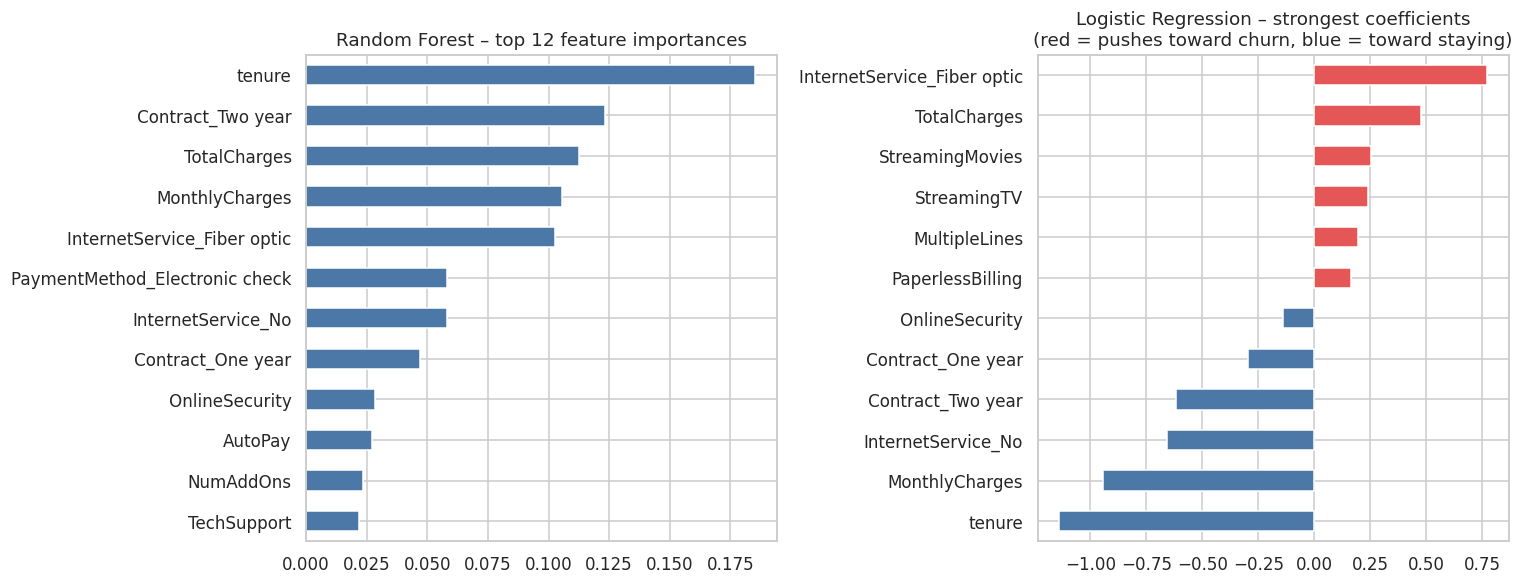

In [31]:
# What does the final model think is important?
rf = models["Random Forest"]
lr = models["Logistic Regression"][-1]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(12)
imp.plot(kind="barh", ax=ax[0], color="#4C78A8"); ax[0].set_title("Random Forest – top 12 feature importances")

coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
coef_plot = pd.concat([coef.head(6), coef.tail(6)])
coef_plot.plot(kind="barh", ax=ax[1], color=["#4C78A8" if v < 0 else "#E45756" for v in coef_plot])
ax[1].set_title("Logistic Regression – strongest coefficients\n(red = pushes toward churn, blue = toward staying)")
plt.tight_layout(); plt.show()

## 7. Application / Prediction
The function below takes **raw customer information** (a dictionary, just like a form filled in by a call-centre agent), applies the *same* preprocessing (`build_features` + one-hot encoding aligned to the training columns) and returns the final model's **churn probability** and a **Churn / No Churn** decision (threshold 0.5).

In [32]:
def predict_churn(customers, threshold=0.5):
    """customers: list of dicts with the raw customer fields. Returns a DataFrame with the prediction."""
    new = pd.DataFrame(customers)
    X_new = pd.get_dummies(build_features(new), columns=MULTI_COLS, dtype=int)
    X_new = X_new.reindex(columns=X.columns, fill_value=0)      # same columns/order as training
    prob = final_model.predict_proba(X_new)[:, 1]
    out = new[["tenure", "Contract", "InternetService", "PaymentMethod", "MonthlyCharges"]].copy()
    out["Churn Probability"] = (prob * 100).round(1).astype(str) + " %"
    out["Prediction"] = np.where(prob >= threshold, "CHURN", "NO CHURN")
    return out

sample_customers = [
    {   # Customer A: new, month-to-month, fiber, electronic check, no extras
        "SeniorCitizen": 0, "Partner": "No", "Dependents": "No", "tenure": 2,
        "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
        "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No", "TechSupport": "No",
        "StreamingTV": "Yes", "StreamingMovies": "Yes", "Contract": "Month-to-month",
        "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
        "MonthlyCharges": 95.70, "TotalCharges": 191.40},
    {   # Customer B: loyal, two-year contract, DSL, automatic payment, many services
        "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes", "tenure": 60,
        "PhoneService": "Yes", "MultipleLines": "Yes", "InternetService": "DSL",
        "OnlineSecurity": "Yes", "OnlineBackup": "Yes", "DeviceProtection": "Yes", "TechSupport": "Yes",
        "StreamingTV": "No", "StreamingMovies": "No", "Contract": "Two year",
        "PaperlessBilling": "No", "PaymentMethod": "Bank transfer (automatic)",
        "MonthlyCharges": 72.40, "TotalCharges": 4350.00},
    {   # Customer C: senior citizen, one-year contract, fiber, mailed check
        "SeniorCitizen": 1, "Partner": "No", "Dependents": "No", "tenure": 14,
        "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
        "OnlineSecurity": "No", "OnlineBackup": "Yes", "DeviceProtection": "No", "TechSupport": "No",
        "StreamingTV": "No", "StreamingMovies": "No", "Contract": "One year",
        "PaperlessBilling": "Yes", "PaymentMethod": "Mailed check",
        "MonthlyCharges": 80.10, "TotalCharges": 1121.40},
    {   # Customer D: long-time customer without internet, only phone
        "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No", "tenure": 45,
        "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "No",
        "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No", "TechSupport": "No",
        "StreamingTV": "No", "StreamingMovies": "No", "Contract": "One year",
        "PaperlessBilling": "No", "PaymentMethod": "Credit card (automatic)",
        "MonthlyCharges": 20.25, "TotalCharges": 911.25},
]
print("Final model used:", final_name, "\n")
predict_churn(sample_customers)

Final model used: Random Forest 



   tenure        Contract InternetService              PaymentMethod  MonthlyCharges Churn Probability Prediction
0       2  Month-to-month     Fiber optic           Electronic check           95.70            88.0 %      CHURN
1      60        Two year             DSL  Bank transfer (automatic)           72.40             4.7 %   NO CHURN
2      14        One year     Fiber optic               Mailed check           80.10            49.9 %   NO CHURN
3      45        One year              No    Credit card (automatic)           20.25             5.0 %   NO CHURN

In [33]:
# Show the input -> output for ONE customer clearly
customer = sample_customers[0]
print("INPUT (customer information):")
for k, v in customer.items():
    print(f"   {k:18s}: {v}")
result = predict_churn([customer]).iloc[0]
print("\nOUTPUT:")
print("   Churn probability:", result["Churn Probability"])
print("   Prediction       :", result["Prediction"])

INPUT (customer information):
   SeniorCitizen     : 0
   Partner           : No
   Dependents        : No
   tenure            : 2
   PhoneService      : Yes
   MultipleLines     : No
   InternetService   : Fiber optic
   OnlineSecurity    : No
   OnlineBackup      : No
   DeviceProtection  : No
   TechSupport       : No
   StreamingTV       : Yes
   StreamingMovies   : Yes
   Contract          : Month-to-month
   PaperlessBilling  : Yes
   PaymentMethod     : Electronic check
   MonthlyCharges    : 95.7
   TotalCharges      : 191.4

OUTPUT:
   Churn probability: 88.0 %
   Prediction       : CHURN


In [34]:
# Sanity check on real customers from the TEST set: model prediction vs. what really happened
sample_idx = X_test.sample(8, random_state=7).index
check = pd.DataFrame({
    "Contract": df_clean.loc[sample_idx, "Contract"],
    "tenure": df_clean.loc[sample_idx, "tenure"],
    "MonthlyCharges": df_clean.loc[sample_idx, "MonthlyCharges"],
    "Actual": np.where(y.loc[sample_idx] == 1, "Churn", "No Churn"),
    "Predicted": np.where(final_model.predict(X_test.loc[sample_idx]) == 1, "Churn", "No Churn"),
})
check["Correct?"] = np.where(check["Actual"] == check["Predicted"], "yes", "NO")
check

            Contract  tenure  MonthlyCharges    Actual Predicted Correct?
5812  Month-to-month       1           71.00     Churn     Churn      yes
3970        One year      42           63.70  No Churn  No Churn      yes
6445  Month-to-month       4           90.65  No Churn     Churn       NO
4986  Month-to-month      12           79.55  No Churn     Churn       NO
6263        One year      25           54.20  No Churn  No Churn      yes
882   Month-to-month       6           83.90     Churn     Churn      yes
4227        Two year      69           80.65  No Churn  No Churn      yes
1606        Two year      72          104.10  No Churn  No Churn      yes

In [35]:
# Save the final model so it can be reused without re-training
joblib.dump({"model": final_model, "columns": list(X.columns), "name": final_name}, "churn_model.joblib")
print("Saved: churn_model.joblib")

Saved: churn_model.joblib


## 8. Conclusion
**Best model:** the **Random Forest** (accuracy 75.4 %, recall 77.3 %, precision 52.5 %, F1 0.625, ROC-AUC 0.845) was selected as the final model, ahead of Logistic Regression and the Decision Tree.

**Important observations from the data**
* About 26.5 % of customers churn, so the data is imbalanced and accuracy alone is misleading (a "never churn" model gets 73.5 %).
* Churn is highest for **month-to-month contracts** (43 %), **fiber-optic users** (42 %), **electronic-check payers** (45 %), **new customers** (47 % churn in the first year), senior citizens and customers without tech support / online security.
* Customers on **two-year contracts, with automatic payment, long tenure and several services** almost never leave.
* Gender has no meaningful effect.

**Limitations**
* Precision is only ≈ 52 %: about one in two customers flagged as "churn" would actually have stayed. The model is useful for *ranking and prioritising* customers, not as a perfect yes/no oracle.
* The dataset has only 7,043 customers and a single snapshot; it contains no information about customer-service complaints, network quality, competitor offers, or price changes, which are real churn drivers.
* The model learns correlations, not causes (e.g. fiber-optic users may churn because of price or service quality – the data cannot tell).
* Results come from one 80/20 split; performance may change on new data or in a different market, and the model needs periodic re-training.
* The 0.5 decision threshold and `class_weight="balanced"` were chosen by us; a company should tune them to its own cost of a lost customer vs. the cost of a retention offer.

**How a telecom company can use it**
1. Score every customer each month and produce a **ranked list of high-risk customers**.
2. Give the retention team targeted offers – e.g. a discount to move a month-to-month customer onto a 1–2 year contract, free tech-support trials, or an incentive to switch from electronic check to automatic payment.
3. Pay special attention to **new customers in their first 12 months** and to fiber-optic customers.
4. Monitor the model's accuracy over time and re-train as customer behaviour changes.